In [1]:
'''
****아래 내용만 잘 알고 있으면 될 것 같음. 모르면 말하쇼. 주석은 최대한 달아놨음****

[EMG 처리 파이프라인]

1. 센서에서 raw EMG 신호 받기

2. 최근 2초 정도 데이터를 버퍼에 저장
   - 새 데이터 들어오면 뒤에 붙이고 앞에꺼 버리는 방식

3. 전처리
   (1) Band-pass filter (20~450 Hz)
       - 저주파 motion artifact + 고주파 노이즈 제거
   (2) Notch filter (60 Hz)
       - 전원 노이즈 제거
   (3) Rectification
       - EMG는 +, - 진동이라 그대로 쓰면 평균이 0 근처로 감
       - abs 씌워서 "근육 활성 크기"로 바꿔주는 단계

4. window 단위로 분석
   - raw sample 하나씩 보는건 의미 없음, 불안정함
   - 일정 구간(window)으로 잘라서 feature 계산
   - 예: window_size = 500 samples, step_size = 100 samples

5. feature 추출
   (1) RMS
       - 근활성 강도 (제일 핵심)
   (2) MAV
       - RMS랑 비슷한 역할 (평균 절댓값)
   (3) Activation ratio
       - 현재 RMS / baseline RMS
       - baseline 대비 얼마나 쓰는지

6. baseline 설정
   - standing 자세 10초
   - 준비 동작 5초
   - 힘 안 준 상태 / 가볍게 준 상태
   - 여기서 mean, std 계산해서 기준값으로 저장

7. baseline과 비교
   - 기본은 ratio 기반이 제일 직관적
   - ratio = current_rms / baseline_rms
   - z-score는:
     (current_rms - baseline_mean) / baseline_std
     → baseline 기준에서 얼마나 벗어났는지 보는 값
     (초기엔 굳이 안 써도 됨)

8. 상태 판정 (heuristic)
   - underactive (활성 부족)
   - good (적절)
   - overactive (과활성)

9. feedback 조건
   - 상태가 일정 시간 유지될 때만 출력
   - 예: 활성 부족이 2초 이상 지속될 때만 경고
   - 순간 튐 방지용

10. 운동 끝나고 요약
    - 평균 RMS
    - baseline 대비 평균 비율
    - 부족/과활성 구간 비율
    - 시간에 따른 변화 등

---------------------------------------------------------
[EX]

- 무지외전근 EMG 1채널
- sampling rate = 1000 Hz

1초 데이터:
data_shape = (1000,)

2초 버퍼:
buffer_shape = (2000,)

분석:
- window = 500 ms (500 samples)
- step = 100 ms (100 samples)

---------------------------------------------------------
[전체 흐름]

Step 1: raw EMG 수집
Step 2: 2초 버퍼 유지
Step 3: bandpass + notch
Step 4: rectification (abs)
Step 5: windowing
Step 6: RMS 계산
Step 7: baseline 대비 ratio 계산
Step 8: threshold 기반 상태 판정
Step 9: 2초 이상 지속 시 feedback
Step 10: 운동 후 전체 요약
'''

import numpy as np  # 수치 계산
from collections import deque  # 오래된 데이터 자동으로 밀어내는 버퍼
from scipy.signal import butter, filtfilt, iirnotch  # 필터용
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

#-------------------------------------------------------------------------
# Preprocessing functions
#-------------------------------------------------------------------------
def bandpass_filter(signal, fs, lowcut=20.0, highcut=450.0, order=4):
    # EMG에서 의미 있는 주파수만 남기기
    # 너무 낮은건 motion artifact, 너무 높은건 노이즈
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)

    return filtered

def notch_filter(signal, fs, notch_freq=60.0, quality_factor=30.0):
    # 전원 노이즈 제거 (한국 기준 60Hz)
    nyquist = 0.5 * fs
    w0 = notch_freq / nyquist

    b, a = iirnotch(w0, quality_factor)
    filtered = filtfilt(b, a, signal)

    return filtered

def rectify_signal(signal):
    # EMG는 + - 진동이라 그대로 평균내면 0 근처로 감
    # abs 씌워서 "근육 활성 크기"로 바꿔주는 단계
    return np.abs(signal)


#-------------------------------------------------------------------------
# Feature extraction
#-------------------------------------------------------------------------
def compute_rms(signal):
    # 근활성 강도 대표값 (제일 중요)
    return np.sqrt(np.mean(signal ** 2))

def compute_mav(signal):
    # RMS랑 거의 비슷한 역할
    return np.mean(np.abs(signal))

def compute_activation_ratio(current_rms, baseline_rms, eps=1e-8):
    # baseline 대비 얼마나 쓰고 있는지
    return current_rms / (baseline_rms + eps)

def process_emg_window(raw_window, fs):
    # 한 window 들어오면 전처리 + feature까지 한번에 처리
    filtered = bandpass_filter(raw_window, fs)
    filtered = notch_filter(filtered, fs)
    rectified = rectify_signal(filtered)

    rms = compute_rms(rectified)
    mav = compute_mav(rectified)

    return {
        "filtered": filtered,
        "rectified": rectified,
        "rms": rms,
        "mav": mav
    }


#-------------------------------------------------------------------------
# Baseline
#-------------------------------------------------------------------------
def make_windows(signal, window_size, step_size):
    # signal을 window 단위로 잘라주는 함수
    # sliding window 방식
    windows = []
    for s in range(0, len(signal) - window_size + 1, step_size):
        e = s + window_size
        windows.append(signal[s: e])

    return windows

def compute_baseline_stats(baseline_signal, fs, window_size, step_size):
    # baseline 구간에서 여러 window로 나눠서
    # RMS / MAV 통계값(mean, std 등) 구하는 부분
    windows = make_windows(baseline_signal, window_size, step_size)

    rms_list, mav_list = [], []

    for w in windows:
        result = process_emg_window(w, fs)
        rms_list.append(result["rms"])
        mav_list.append(result["mav"])

    baseline_stats = {
        "rms_mean": np.mean(rms_list),   # baseline 평균
        "rms_std": np.std(rms_list),     # baseline 변동성
        "rms_median": np.median(rms_list),
        "mav_mean": np.mean(mav_list),
        "mav_std": np.std(mav_list),
        "mav_median": np.median(mav_list),
    }
    return baseline_stats


#-------------------------------------------------------------------------
# Make decisions
#-------------------------------------------------------------------------
def judge_emg_state(ratio, low_thresh=0.7, high_thresh=1.5):
    # baseline 대비 얼마나 쓰는지로 상태 판단
    if ratio < low_thresh:
        return "underactive"   # 덜 쓰는 상태
    elif ratio <= high_thresh:
        return "good"          # 적절
    else:
        return "overactive"    # 과하게 힘 줌


#-------------------------------------------------------------------------
# Feedback
#-------------------------------------------------------------------------
def generate_feedback(state):
    if state == "underactive":
        return "무지외전근 활성도가 낮습니다. 엄지 쪽에 힘을 조금 더 실어보세요."
    elif state == "good":
        return "좋습니다. 현재 무지외전근 사용이 적절하게 유지되고 있습니다."
    elif state == "overactive":
        return "힘이 조금 과하게 들어가고 있습니다. 발에 힘을 너무 주지 말고 자연스럽게 유지해보세요."
    else:
        return "상태를 판단할 수 없습니다."


#-------------------------------------------------------------------------
# For Real-time Processing
#-------------------------------------------------------------------------
class EMGMonitor:
    def __init__(
        self,
        fs=1000,
        buffer_seconds=2.0,
        window_ms=500,
        step_ms=100,
        low_thresh=0.7,
        high_thresh=1.5
    ):
        self.fs = fs
        # 2초 버퍼 (deque가 자동으로 오래된거 밀어냄)
        self.buffer_size = int(buffer_seconds * fs)
        # window / step (ms → sample 변환)
        self.window_size = int(window_ms * fs / 1000)
        self.step_size = int(step_ms * fs / 1000)
        self.low_thresh = low_thresh
        self.high_thresh = high_thresh
        self.buffer = deque(maxlen=self.buffer_size)
        self.baseline_stats = None  # baseline 아직 안 넣은 상태
        # 기록용
        self.state_history = []
        self.feature_history = []

    def update_buffer(self, new_samples):
        # 새 EMG 들어오면 버퍼에 계속 추가
        for x in new_samples:
            self.buffer.append(float(x))

    def set_baseline(self, baseline_signal):
        # baseline 계산해서 저장
        self.baseline_stats = compute_baseline_stats(
            baseline_signal=baseline_signal,
            fs=self.fs,
            window_size=self.window_size,
            step_size=self.step_size
        )

    def analyze_current_window(self):
        # 현재 버퍼 기준으로 최신 window 분석
        if len(self.buffer) < self.window_size:
            return None  # 아직 데이터 부족

        current_window = np.array(list(self.buffer)[-self.window_size:])

        result = process_emg_window(current_window, self.fs)

        rms = result["rms"]
        mav = result["mav"]

        ratio = compute_activation_ratio(rms, self.baseline_stats["rms_mean"])

        state = judge_emg_state(ratio, self.low_thresh, self.high_thresh)
        feedback = generate_feedback(state)

        output = {
            "rms": rms,
            "mav": mav,
            "ratio": ratio,
            "state": state,
            "feedback": feedback
        }

        # 기록 쌓기
        self.state_history.append(state)
        self.feature_history.append(output)

        return output

    def check_persistent_underactive(self, duration_seconds=2.0):
        # underactive 상태가 일정 시간 이상 지속됐는지 확인
        step_ms = int(self.step_size * 1000 / self.fs)
        required_steps = int(duration_seconds * 1000 / step_ms)

        if len(self.state_history) < required_steps:
            return False

        recent_states = self.state_history[-required_steps:]

        return all(s == "underactive" for s in recent_states)

    def summarize_session(self):
        # 운동 끝나고 전체 요약
        if len(self.feature_history) == 0:
            return None

        ratios = [x["ratio"] for x in self.feature_history]
        rms_values = [x["rms"] for x in self.feature_history]
        states = [x["state"] for x in self.feature_history]

        summary = {
            "avg_rms": float(np.mean(rms_values)),
            "avg_ratio": float(np.mean(ratios)),
            "underactive_ratio": states.count("underactive") / len(states),
            "good_ratio": states.count("good") / len(states),
            "overactive_ratio": states.count("overactive") / len(states),
            "num_windows": len(states)
        }

        return summary


#-------------------------------------------------------------------------
# Report
#-------------------------------------------------------------------------
def state_to_score(state):
    if state == "underactive":
        return 0
    elif state == "good":
        return 1
    elif state == "overactive":
        return 2
    else:
        return -1

def state_to_score(state):
    if state == "underactive":
        return 0
    elif state == "good":
        return 1
    elif state == "overactive":
        return 2
    else:
        return -1

def history_to_dataframe(monitor):
    if len(monitor.feature_history) == 0:
        return None

    df = pd.DataFrame(monitor.feature_history).copy()
    df["window_idx"] = np.arange(len(df))
    df["time_sec"] = df["window_idx"] * (monitor.step_size / monitor.fs)
    df["state_score"] = df["state"].apply(state_to_score)

    return df

def print_session_summary(monitor):
    summary = monitor.summarize_session()

    if summary is None:
        print("요약할 데이터가 없음")
        return

    print("\n" + "=" * 50)
    print("운동 후 요약")
    print("=" * 50)
    print(f"평균 RMS              : {summary['avg_rms']:.4f}")
    print(f"평균 Activation Ratio : {summary['avg_ratio']:.2f}")
    print(f"underactive 비율      : {summary['underactive_ratio']:.2%}")
    print(f"good 비율             : {summary['good_ratio']:.2%}")
    print(f"overactive 비율       : {summary['overactive_ratio']:.2%}")
    print(f"총 window 수          : {summary['num_windows']}")

    avg_ratio = summary["avg_ratio"]

    if avg_ratio < 0.7:
        print("총평: 전체적으로 근육 사용이 부족한 편")
    elif avg_ratio <= 1.5:
        print("총평: 전체적으로 적절한 근육 사용 유지")
    else:
        print("총평: 전체적으로 힘이 다소 과하게 들어간 편")
        
def plot_session_analysis(monitor, title="EMG Session Analysis"):
    df = history_to_dataframe(monitor)

    if df is None or len(df) == 0:
        print("그릴 데이터가 없음")
        return

    sns.set_theme(style="whitegrid", context="talk")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(title, fontsize=18)

    # -------------------------------------------------
    # 1) RMS over time
    # -------------------------------------------------
    sns.lineplot(
        data=df,
        x="time_sec",
        y="rms",
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("RMS over time")
    axes[0, 0].set_xlabel("Time (s)")
    axes[0, 0].set_ylabel("RMS")

    # -------------------------------------------------
    # 2) Ratio over time + threshold line
    # -------------------------------------------------
    sns.lineplot(
        data=df,
        x="time_sec",
        y="ratio",
        hue="state",
        palette={
            "underactive": "royalblue",
            "good": "seagreen",
            "overactive": "tomato"
        },
        ax=axes[0, 1]
    )
    axes[0, 1].axhline(monitor.low_thresh, linestyle="--", color="blue", alpha=0.7, label="low_thresh")
    axes[0, 1].axhline(monitor.high_thresh, linestyle="--", color="red", alpha=0.7, label="high_thresh")
    axes[0, 1].set_title("Activation ratio over time")
    axes[0, 1].set_xlabel("Time (s)")
    axes[0, 1].set_ylabel("Ratio")
    handles, labels = axes[0, 1].get_legend_handles_labels()
    axes[0, 1].legend(handles, labels, fontsize=9)

    # -------------------------------------------------
    # 3) State count
    # -------------------------------------------------
    sns.countplot(
        data=df,
        x="state",
        order=["underactive", "good", "overactive"],
        palette={
            "underactive": "royalblue",
            "good": "seagreen",
            "overactive": "tomato"
        },
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("State distribution")
    axes[1, 0].set_xlabel("State")
    axes[1, 0].set_ylabel("Count")

    # -------------------------------------------------
    # 4) Ratio distribution
    # -------------------------------------------------
    sns.histplot(
        data=df,
        x="ratio",
        hue="state",
        bins=20,
        kde=True,
        palette={
            "underactive": "royalblue",
            "good": "seagreen",
            "overactive": "tomato"
        },
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Ratio distribution")
    axes[1, 1].set_xlabel("Activation Ratio")
    axes[1, 1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

### Dummy data test

In [2]:
def generate_dummy_emg(duration_sec=10, fs=1000, amplitude=0.02):
    t = np.linspace(0, duration_sec, duration_sec * fs)

    # 빠른 진동 (EMG-like noise)
    noise = np.random.randn(len(t))

    # 천천히 변하는 envelope (근활성 변화)
    envelope = 1 + 0.5 * np.sin(2 * np.pi * 0.5 * t)  # 0.5Hz

    signal = amplitude * envelope * noise

    return signal

dummy = generate_dummy_emg()
print(dummy.shape)

baseline_signal = generate_dummy_emg(duration_sec=10, amplitude=0.02)

monitor = EMGMonitor(fs=1000)
monitor.set_baseline(baseline_signal)

print(monitor.baseline_stats)

(10000,)
{'rms_mean': np.float64(0.01859132056063063), 'rms_std': np.float64(0.0056730088427823155), 'rms_median': np.float64(0.01894496910644), 'mav_mean': np.float64(0.014696311992702119), 'mav_std': np.float64(0.004634108140492307), 'mav_median': np.float64(0.014758663999933912)}



UNDER TEST START
[Baseline stats]
    rms_mean: 0.018541
     rms_std: 0.005905
  rms_median: 0.018510
    mav_mean: 0.014608
     mav_std: 0.004776
  mav_median: 0.014464

운동 후 요약
평균 RMS              : 0.0049
평균 Activation Ratio : 0.26
underactive 비율      : 100.00%
good 비율             : 0.00%
overactive 비율       : 0.00%
총 window 수          : 46
총평: 전체적으로 근육 사용이 부족한 편


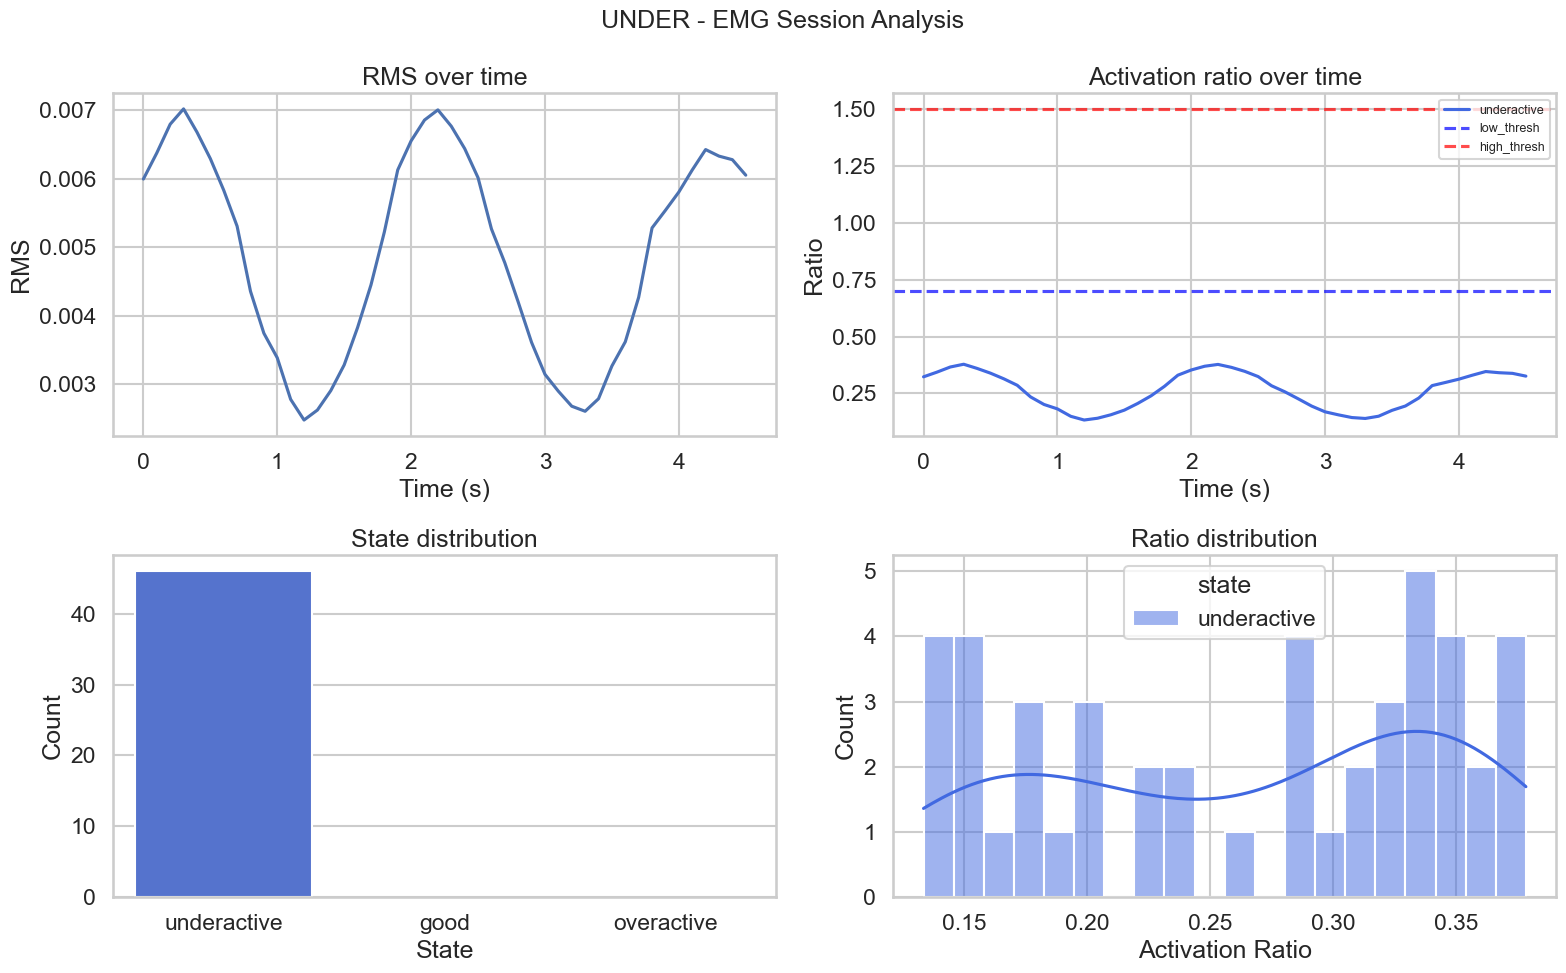


GOOD TEST START
[Baseline stats]
    rms_mean: 0.018573
     rms_std: 0.005816
  rms_median: 0.019134
    mav_mean: 0.014647
     mav_std: 0.004720
  mav_median: 0.014699

운동 후 요약
평균 RMS              : 0.0194
평균 Activation Ratio : 1.05
underactive 비율      : 21.74%
good 비율             : 78.26%
overactive 비율       : 0.00%
총 window 수          : 46
총평: 전체적으로 적절한 근육 사용 유지


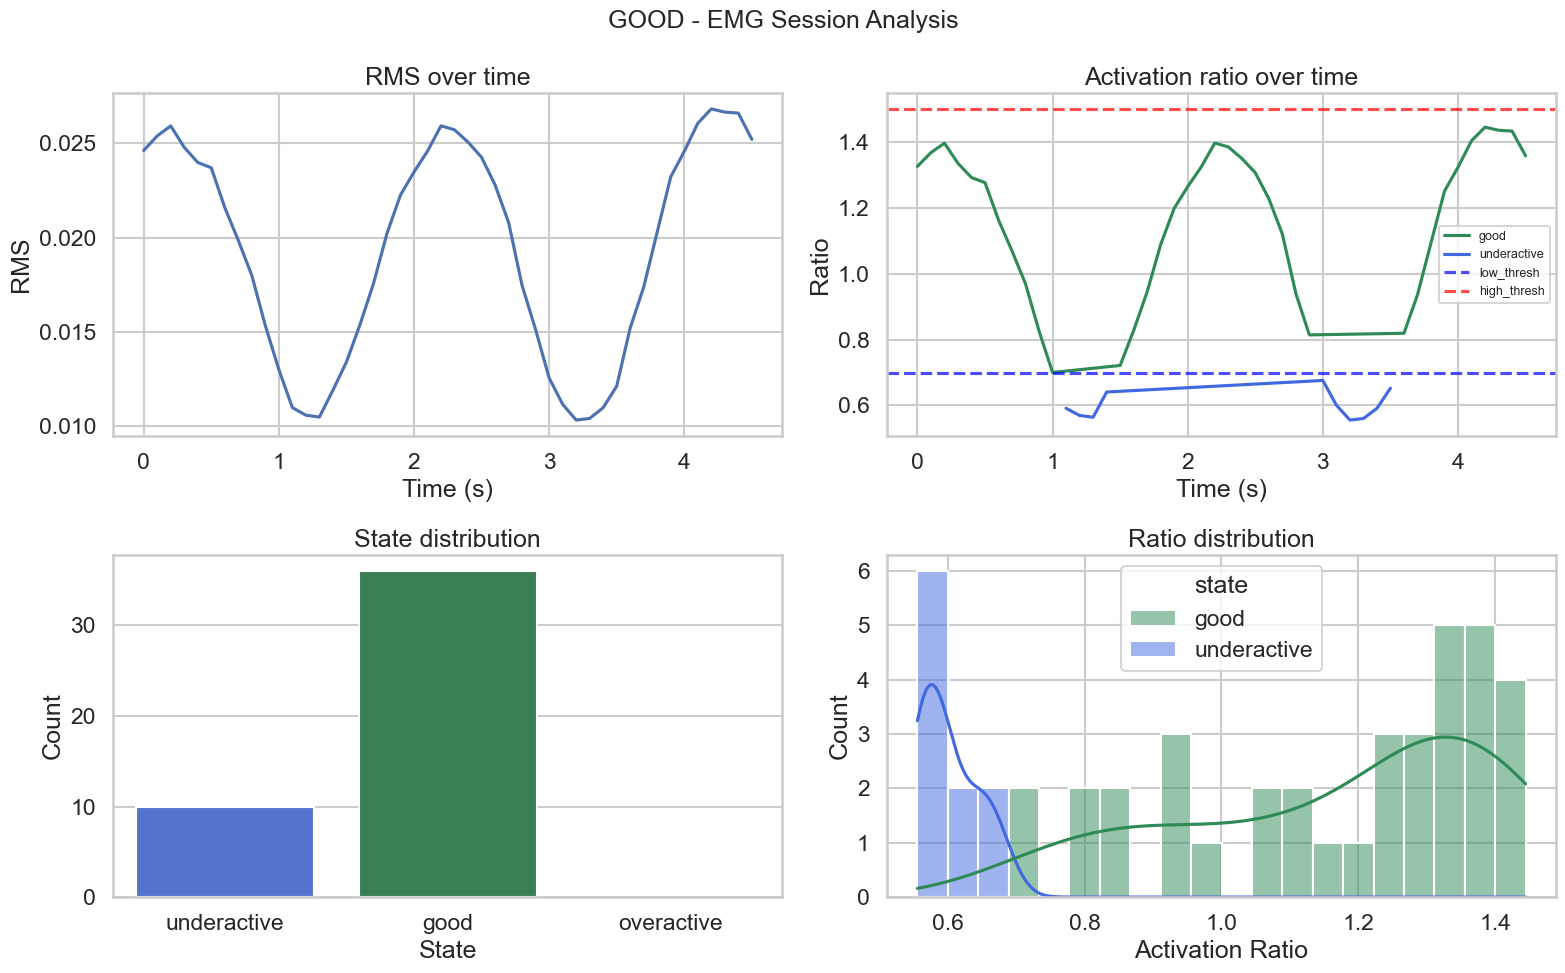


OVER TEST START
[Baseline stats]
    rms_mean: 0.018290
     rms_std: 0.006035
  rms_median: 0.018080
    mav_mean: 0.014396
     mav_std: 0.004892
  mav_median: 0.014076

운동 후 요약
평균 RMS              : 0.0788
평균 Activation Ratio : 4.31
underactive 비율      : 0.00%
good 비율             : 0.00%
overactive 비율       : 100.00%
총 window 수          : 46
총평: 전체적으로 힘이 다소 과하게 들어간 편


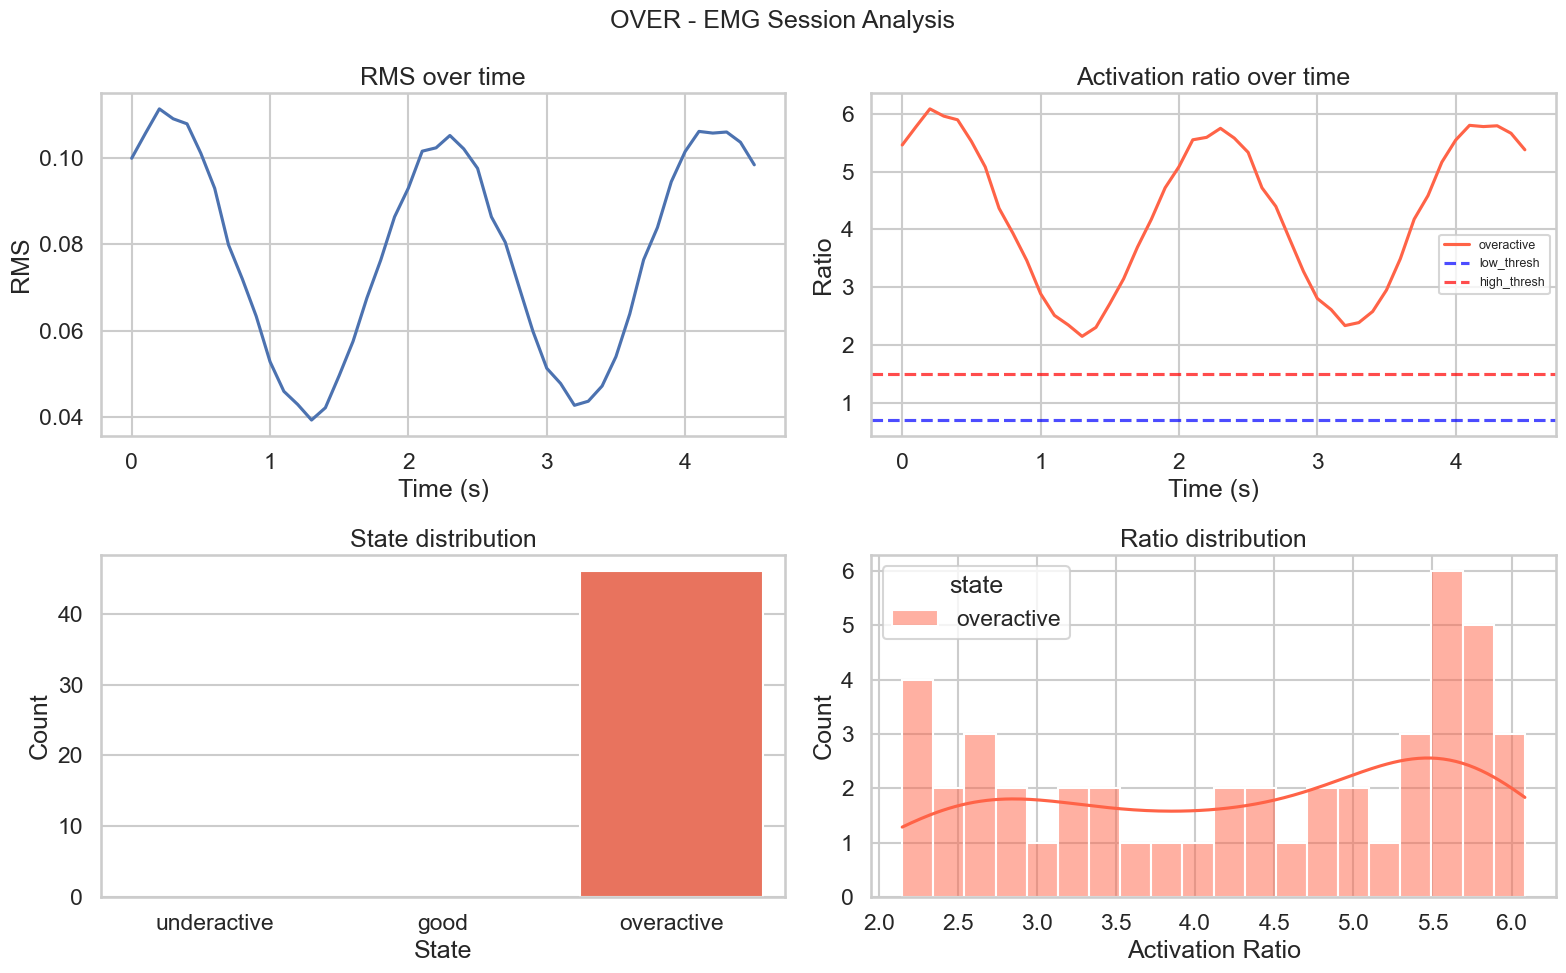

In [3]:
def run_test(signal, label="TEST", baseline_amplitude=0.02, verbose=True):
    print(f"\n{'='*60}")
    print(f"{label} TEST START")
    print(f"{'='*60}")

    monitor = EMGMonitor(fs=1000)

    baseline_signal = generate_dummy_emg(duration_sec=10, amplitude=baseline_amplitude)
    monitor.set_baseline(baseline_signal)

    print("[Baseline stats]")
    for k, v in monitor.baseline_stats.items():
        print(f"{k:>12}: {v:.6f}")

    chunk_size = 100

    for i in range(0, len(signal), chunk_size):
        chunk = signal[i:i+chunk_size]
        monitor.update_buffer(chunk)

        result = monitor.analyze_current_window()

        if result is not None and verbose:
            print(
                f"[{i//chunk_size:03d}] "
                f"RMS={result['rms']:.4f} | "
                f"MAV={result['mav']:.4f} | "
                f"Ratio={result['ratio']:.2f} | "
                f"State={result['state']} | "
                f"Feedback={result['feedback']}"
            )

            if monitor.check_persistent_underactive(duration_seconds=2.0):
                print("경고: 활성 부족 상태가 2초 이상 지속 중")

    print_session_summary(monitor)
    plot_session_analysis(monitor, title=f"{label} - EMG Session Analysis")

    return monitor


test_under = generate_dummy_emg(duration_sec=5, amplitude=0.005)
test_good  = generate_dummy_emg(duration_sec=5, amplitude=0.02)
test_over  = generate_dummy_emg(duration_sec=5, amplitude=0.08)

monitor_under = run_test(test_under, label="UNDER", verbose=False)
monitor_good  = run_test(test_good,  label="GOOD",  verbose=False)
monitor_over  = run_test(test_over,  label="OVER",  verbose=False)